6 Month Analysis

In [5]:
from scipy import stats
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.stats.multitest import multipletests

def map_labels_to_colors(labels, colormap="tab20"):
        unique_labels = np.unique(labels)
        cmap = plt.get_cmap('tab20')
        colors = [cmap(i) for i in range(len(unique_labels))]
        label_to_color = {label: colors[i % len(colors)] for i, label in enumerate(unique_labels)}
        return label_to_color

with open("data/lipid_names.txt", "r") as f:
    lipid_names = [line.strip() for line in f]
lipid_N_reduced_list = pd.read_csv('data/negative_globus_pallidus_ion_clustering_using_logfc_patterns_over_time.csv').iloc[:, 0].tolist()
reduced_indices = [lipid_names.index(item) for item in lipid_N_reduced_list]

clusters = np.load('checkpoints/clusters_[\'6moWT_0\', \'6moWT_1\', \'6moWT_2\', \'6moAD_0\', \'6moAD_1\', \'6moAD_2\'].npy')
label_to_color = map_labels_to_colors(clusters)
clusters[clusters == 11] = 15

coords = [np.load('data/6moWT_0_coords.npy'), np.load('data/6moWT_1_coords.npy'), np.load('data/6moWT_2_coords.npy'), np.load('data/6moAD_0_coords.npy'), np.load('data/6moAD_1_coords.npy'), np.load('data/6moAD_2_coords.npy')]
abundances = [np.load('data/6moWT_0_lipids.npy'), np.load('data/6moWT_1_lipids.npy'), np.load('data/6moAD_0_lipids.npy'), np.load('data/6moAD_1_lipids.npy'), np.load('data/6moAD_2_lipids.npy')]
clusters = np.hstack((clusters[0:coords[0].shape[0] + coords[1].shape[0]], clusters[coords[0].shape[0] + coords[1].shape[0] + coords[2].shape[0]:]))
coords = coords[0:2] + coords[3:]
for i in range(len(abundances)):
    abundances[i] = abundances[i][:, reduced_indices]
    abundances[i] = abundances[i] / abundances[i].sum(axis=1, keepdims=True)
    
# 1. Concatenate the arrays along the first axis (axis=0)
concatenated = np.vstack(abundances)  # Concatenate along rows (n dimension)

# 2. Z-score normalization across the concatenated array (column-wise normalization)
concatenated_zscore = (concatenated - concatenated.mean(axis=0)) / concatenated.std(axis=0)

# 3. Split the concatenated and normalized array back into the original arrays
abundances = np.split(concatenated_zscore, np.cumsum([arr.shape[0] for arr in abundances])[:-1])

data = []
curr = 0
i = 0
for c in coords:
    data.append((c, clusters[curr:curr + c.shape[0]], abundances[i]))
    curr += c.shape[0]
    i+= 1

hemispheres = []
i = 0
for (c, l, a) in data:
    if i != 4:
        median_x_coord = np.median(c[:, 0])
        hemispheres.append((c[np.where(c[:, 0] < median_x_coord)[0]], l[np.where(c[:, 0] < median_x_coord)[0]], a[np.where(c[:, 0] < median_x_coord)[0]]))
        hemispheres.append((c[np.where(c[:, 0] >= median_x_coord)[0]], l[np.where(c[:, 0] >= median_x_coord)[0]], a[np.where(c[:, 0] >= median_x_coord)[0]]))
    else:
        median_y_coord = np.median(c[:, 1])
        hemispheres.append((c[np.where(c[:, 1] < median_y_coord)[0]], l[np.where(c[:, 1] < median_y_coord)[0]], a[np.where(c[:, 1] < median_y_coord)[0]]))
        hemispheres.append((c[np.where(c[:, 1] >= median_y_coord)[0]], l[np.where(c[:, 1] >= median_y_coord)[0]], a[np.where(c[:, 1] >= median_y_coord)[0]]))
    i += 1

WT = hemispheres[0:4]
AD = hemispheres[4:]
i = 0
legend_patches = [mpatches.Patch(color=color, label=label) for label, color in label_to_color.items()]
for h in WT + AD:
    #print(i // 2)
    #plt.scatter(x=h[0][:, 0], y=h[0][:, 1], c=[label_to_color[label] for label in h[1]])
    #plt.scatter(x=h[0][:, 0], y=h[0][:, 1], c=h[2][:, 1])
    #plt.legend(handles=legend_patches)
    #plt.show()
    i += 1

res = {}
for cluster in np.unique(clusters):
    p_values = []
    for ion in range(WT[0][2].shape[1]):
        wt_means = []
        ad_means = []
        for x in WT:
            wt_means.append(np.mean(x[2][x[1] == cluster, ion]))
        for x in AD:
            ad_means.append(np.mean(x[2][x[1] == cluster, ion]))
        t_stat, p_value = stats.ttest_ind(wt_means, ad_means)
        p_values.append(p_value)
    _, p_values, _, _ = multipletests(p_values, method='fdr_bh', alpha=0.05)
    res[cluster] = {}
    for i in range(len(p_values)):
        res[cluster][lipid_N_reduced_list[i]] = p_values[i]

df = pd.DataFrame.from_dict(res, orient='index')
df.dropna(inplace=True)
df


/opt/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


,884.5394,685.5149,729.5485,883.5340,883.5327,838.5569,862.6049,806.5424,752.5344,729.5460,...,695.4633,905.6254,723.4531,699.4911,700.5164,836.5371,674.4805,810.5298,858.5237,878.6012
0,0.960505,0.643045,0.383485,0.588898,0.412536,0.528333,0.662886,0.290953,0.347732,0.409578,...,0.655320,0.875237,0.694015,0.692686,0.253053,0.381226,0.977246,0.801803,0.416153,0.801803
1,0.631685,0.438691,0.586138,0.851403,0.942221,0.609534,0.847291,0.685578,0.726339,0.538036,...,0.250633,0.393339,0.294425,0.250633,0.385723,0.458575,0.250633,0.250633,0.507719,0.538036
2,0.064313,0.392237,0.748287,0.003050,0.003050,0.064313,0.761047,0.756629,0.399402,0.898287,...,0.306696,0.877791,0.975782,0.421701,0.191480,0.001502,0.395932,0.788120,0.171586,0.898287
3,0.189533,0.424146,0.508367,0.010999,0.005805,0.121837,0.953465,0.419446,0.562701,0.556055,...,0.331644,0.909485,0.477253,0.509556,0.331272,0.002382,0.382068,0.527208,0.593519,0.724820
4,0.880042,0.482755,0.468613,0.697855,0.678978,0.468613,0.624833,0.481077,0.743875,0.341539,...,0.971162,0.482755,0.744526,0.797531,0.329004,0.647593,0.824069,0.647593,0.618125,0.555718
5,0.967544,0.254577,0.204161,0.765508,0.671894,0.715998,0.835824,0.408131,0.253749,0.226746,...,0.928549,0.078731,0.903668,0.112370,0.725861,0.898131,0.186940,0.573559,0.898131,0.568353
7,0.639962,0.843000,0.862107,0.455624,0.455624,0.729389,0.999671,0.725115,0.725115,0.700582,...,0.725115,0.796959,0.855604,0.913696,0.522858,0.682775,0.930778,0.759174,0.835990,0.930778
8,0.222294,0.031670,0.012980,0.063395,0.043073,0.009727,0.037083,0.074344,0.111012,0.007811,...,0.235162,0.016335,0.292806,0.135398,0.017275,0.002235,0.154345,0.115996,0.799967,0.047551
9,0.946710,0.940152,0.939322,0.940152,0.962711,0.939322,0.962711,0.940152,0.939322,0.939322,...,0.939322,0.939322,0.939322,0.962711,0.962711,0.939322,0.952510,0.939322,0.939322,0.939322
13,0.110041,0.055601,0.063363,0.174751,0.143321,0.507684,0.282152,0.943911,0.484464,0.051190,...,0.083930,0.060158,0.150875,0.047990,0.074907,0.096173,0.052571,0.982780,0.072135,0.143791


12 Month Analysis

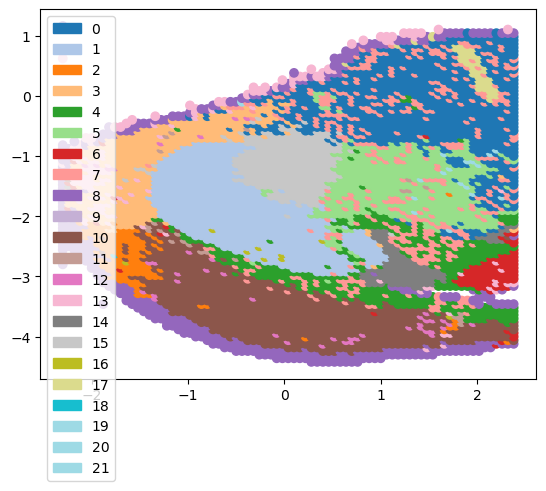

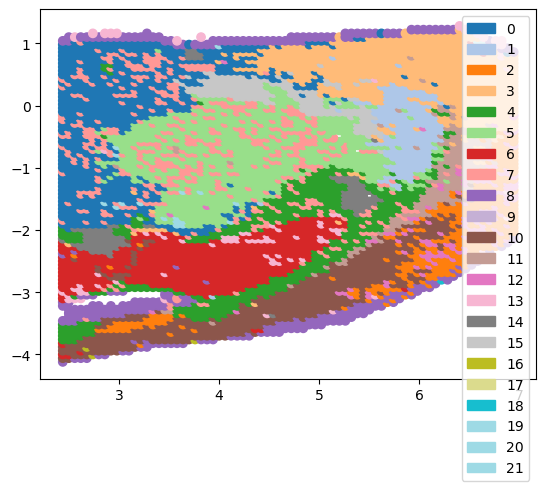

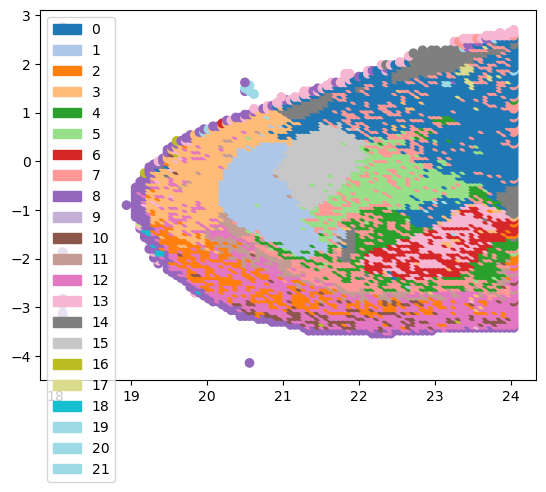

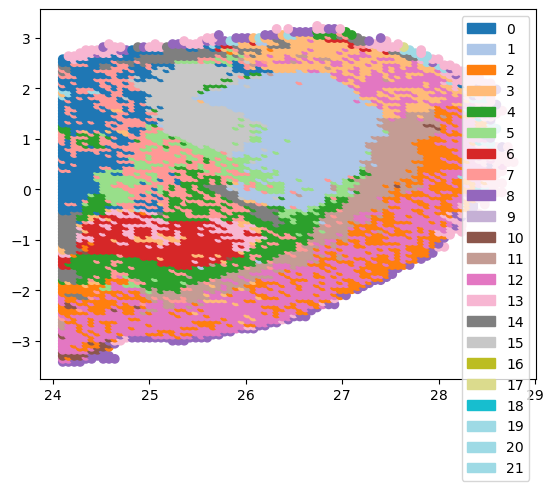

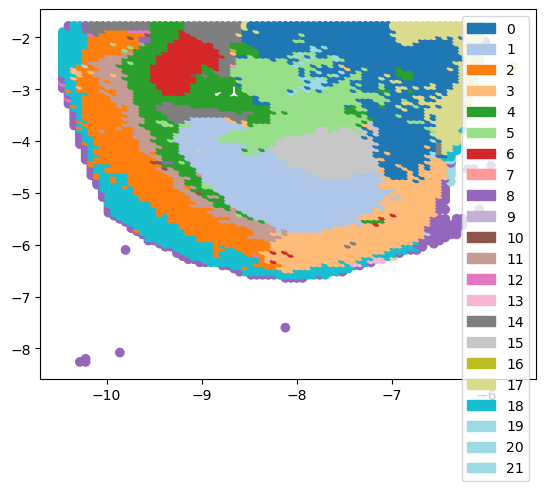

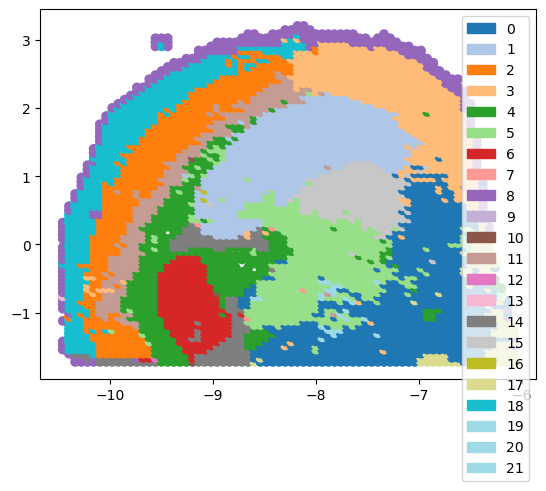

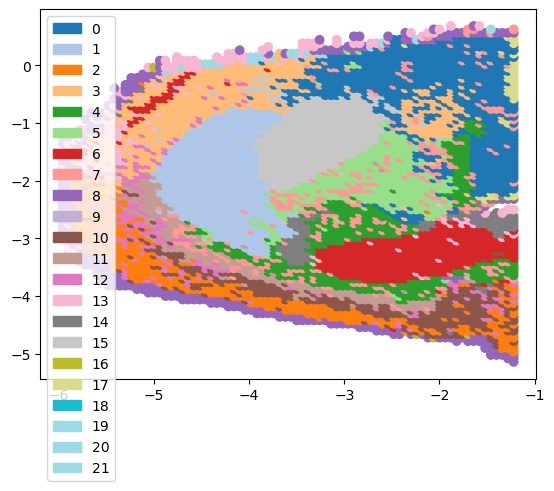

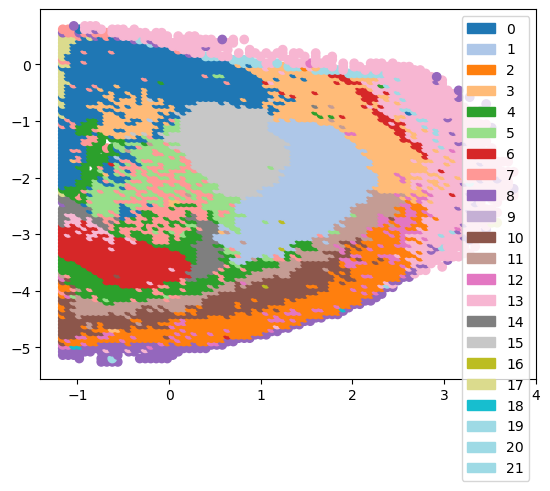

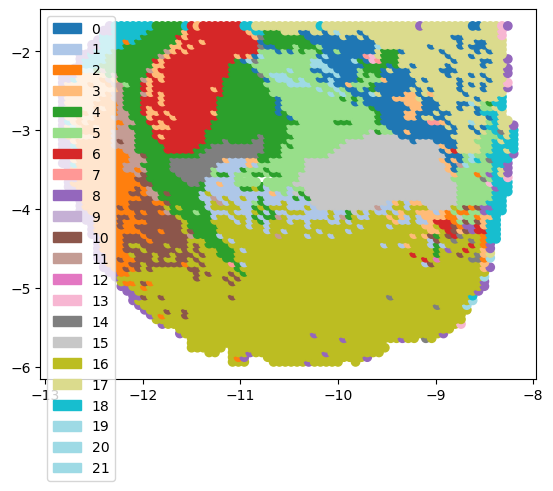

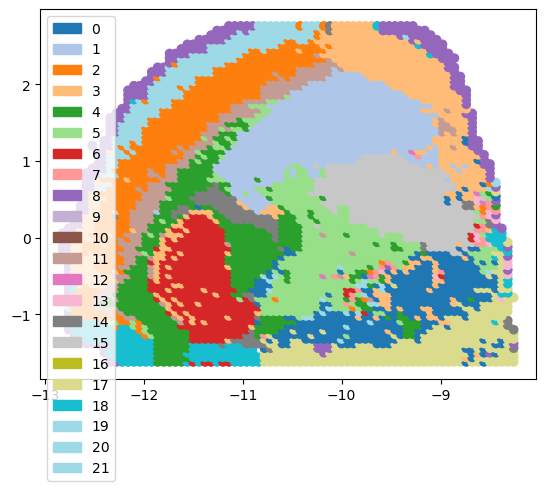

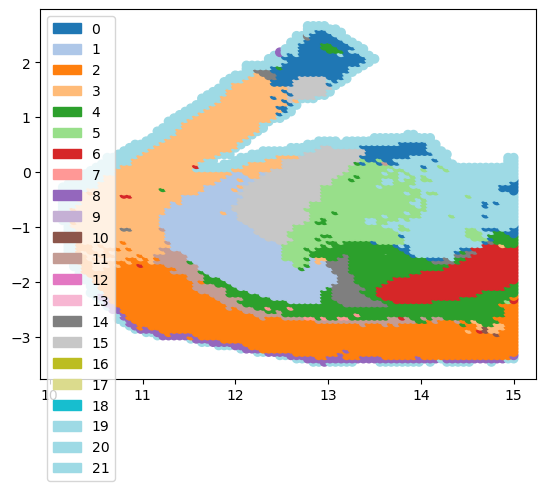

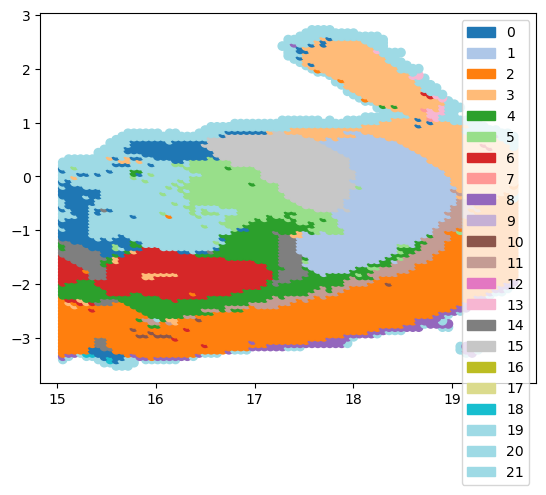

/opt/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


,884.5394,685.5149,729.5485,883.5340,883.5327,838.5569,862.6049,806.5424,752.5344,729.5460,...,695.4633,905.6254,723.4531,699.4911,700.5164,836.5371,674.4805,810.5298,858.5237,878.6012
0,0.991800,0.991800,0.991800,0.991800,0.991800,0.991800,0.991800,0.991800,0.991800,0.991800,...,0.991800,0.991800,0.993809,0.991800,0.991800,0.991800,0.991800,0.991800,0.991800,0.991800
1,0.754244,0.628389,0.759526,0.754244,0.754244,0.759526,0.718199,0.666022,0.961820,0.754244,...,0.818066,0.754244,0.980683,0.754244,0.754244,0.818066,0.754244,0.754244,0.754244,0.754244
2,0.708895,0.879652,0.807161,0.807161,0.522790,0.875227,0.932442,0.807161,0.807161,0.807161,...,0.807161,0.993215,0.807161,0.807161,0.807161,0.727838,0.807161,0.807161,0.527253,0.809811
3,0.869384,0.900321,0.964088,0.900321,0.869384,0.945424,0.945424,0.900321,0.991210,0.945424,...,0.945424,0.945424,0.960522,0.962174,0.945424,0.900321,0.993937,0.991216,0.869384,0.945424
4,0.914470,0.914470,0.914470,0.929681,0.929681,0.928190,0.914470,0.914470,0.914470,0.914470,...,0.952522,0.914470,0.914470,0.950540,0.914470,0.914470,0.914470,0.983288,0.914470,0.950540
5,0.981137,0.981137,0.981137,0.981137,0.981137,0.981137,0.981137,0.981137,0.981137,0.981137,...,0.981137,0.981137,0.981137,0.981137,0.981137,0.981137,0.981137,0.981137,0.981137,0.981137
6,0.260588,0.441365,0.361138,0.260588,0.260588,0.318515,0.973750,0.382493,0.881429,0.382493,...,0.327625,0.962753,0.385605,0.410620,0.260588,0.260588,0.377388,0.409292,0.298028,0.982074
7,0.997696,0.997696,0.997696,0.997696,0.997696,0.997696,0.997696,0.997696,0.997696,0.997696,...,0.997696,0.997696,0.997696,0.997696,0.997696,0.997696,0.997696,0.997696,0.997696,0.997696
8,0.589291,0.354892,0.303634,0.503288,0.486618,0.790977,0.686893,0.259395,0.697737,0.252822,...,0.259601,0.860878,0.499142,0.259395,0.303634,0.506000,0.252822,0.918103,0.547803,0.697551
11,0.883585,0.836783,0.869344,0.944000,0.854660,0.944000,0.854660,0.836783,0.927240,0.836783,...,0.945594,0.854660,0.945594,0.944000,0.944000,0.944000,0.898638,0.944000,0.944000,0.898638


In [7]:
clusters = np.load('checkpoints/clusters_[\'12moWT_0\', \'12moWT_1\', \'12moWT_2\', \'12moAD_0\', \'12moAD_1\', \'12moAD_2\'].npy')
label_to_color = map_labels_to_colors(clusters)
clusters[clusters == 9] = 15

coords = [np.load('data/12moWT_0_coords.npy'), np.load('data/12moWT_1_coords.npy'), np.load('data/12moWT_2_coords.npy'), np.load('data/12moAD_0_coords.npy'), np.load('data/12moAD_1_coords.npy'), np.load('data/12moAD_2_coords.npy')]
abundances = [np.load('data/12moWT_0_lipids.npy'), np.load('data/12moWT_1_lipids.npy'), np.load('data/12moWT_2_lipids.npy'), np.load('data/12moAD_0_lipids.npy'), np.load('data/12moAD_1_lipids.npy'), np.load('data/12moAD_2_lipids.npy')]
for i in range(len(abundances)):
    abundances[i] = abundances[i][:, reduced_indices]
    abundances[i] = abundances[i] / abundances[i].sum(axis=1, keepdims=True)
    
# 1. Concatenate the arrays along the first axis (axis=0)
concatenated = np.vstack(abundances)  # Concatenate along rows (n dimension)

# 2. Z-score normalization across the concatenated array (column-wise normalization)
concatenated_zscore = (concatenated - concatenated.mean(axis=0)) / concatenated.std(axis=0)

# 3. Split the concatenated and normalized array back into the original arrays
abundances = np.split(concatenated_zscore, np.cumsum([arr.shape[0] for arr in abundances])[:-1])

data = []
curr = 0
i = 0
for c in coords:
    data.append((c, clusters[curr:curr + c.shape[0]], abundances[i]))
    curr += c.shape[0]
    i+= 1

hemispheres = []
i = 0
for (c, l, a) in data:
    if i == 0  or i == 1 or i == 3 or i == 5:
        median_x_coord = np.median(c[:, 0])
        hemispheres.append((c[np.where(c[:, 0] < median_x_coord)[0]], l[np.where(c[:, 0] < median_x_coord)[0]], a[np.where(c[:, 0] < median_x_coord)[0]]))
        hemispheres.append((c[np.where(c[:, 0] >= median_x_coord)[0]], l[np.where(c[:, 0] >= median_x_coord)[0]], a[np.where(c[:, 0] >= median_x_coord)[0]]))
    else:
        median_y_coord = np.median(c[:, 1])
        hemispheres.append((c[np.where(c[:, 1] < median_y_coord)[0]], l[np.where(c[:, 1] < median_y_coord)[0]], a[np.where(c[:, 1] < median_y_coord)[0]]))
        hemispheres.append((c[np.where(c[:, 1] >= median_y_coord)[0]], l[np.where(c[:, 1] >= median_y_coord)[0]], a[np.where(c[:, 1] >= median_y_coord)[0]]))
    i += 1

WT = hemispheres[0:6]
AD = hemispheres[6:]
i = 0
legend_patches = [mpatches.Patch(color=color, label=label) for label, color in label_to_color.items()]
for h in WT + AD:
    #print(i // 2)
    plt.scatter(x=h[0][:, 0], y=h[0][:, 1], c=[label_to_color[label] for label in h[1]])
    #plt.scatter(x=h[0][:, 0], y=h[0][:, 1], c=h[2][:, 1])
    plt.legend(handles=legend_patches)
    plt.show()
    i += 1

res = {}
for cluster in np.unique(clusters):
    p_values = []
    for ion in range(WT[0][2].shape[1]):
        wt_means = []
        ad_means = []
        for x in WT:
            wt_means.append(np.mean(x[2][x[1] == cluster, ion]))
        for x in AD:
            ad_means.append(np.mean(x[2][x[1] == cluster, ion]))
        t_stat, p_value = stats.ttest_ind(wt_means, ad_means)
        p_values.append(p_value)
    _, p_values, _, _ = multipletests(p_values, method='fdr_bh', alpha=0.05)
    res[cluster] = {}
    for i in range(len(p_values)):
        res[cluster][lipid_N_reduced_list[i]] = p_values[i]
df = pd.DataFrame.from_dict(res, orient='index')
df.dropna(inplace=True)
df

22 Month Analysis

In [ ]:
clusters = np.load('checkpoints/clusters_[\'22moWT_0\', \'22moWT_1\', \'22moWT_2\', \'22moAD_0\', \'22moAD_1\', \'22moAD_2\'].npy')
label_to_color = map_labels_to_colors(clusters)

coords = [np.load('data/22moWT_0_coords.npy'), np.load('data/22moWT_1_coords.npy'), np.load('data/22moWT_2_coords.npy'), np.load('data/22moAD_0_coords.npy'), np.load('data/22moAD_1_coords.npy'), np.load('data/22moAD_2_coords.npy')]
abundances = [np.load('data/22moWT_0_lipids.npy'), np.load('data/22moWT_1_lipids.npy'), np.load('data/22moWT_2_lipids.npy'), np.load('data/22moAD_0_lipids.npy'), np.load('data/22moAD_1_lipids.npy'), np.load('data/22moAD_2_lipids.npy')]
for i in range(len(abundances)):
    abundances[i] = abundances[i][:, reduced_indices]
    abundances[i] = abundances[i] / abundances[i].sum(axis=1, keepdims=True)
    
# 1. Concatenate the arrays along the first axis (axis=0)
concatenated = np.vstack(abundances)  # Concatenate along rows (n dimension)

# 2. Z-score normalization across the concatenated array (column-wise normalization)
concatenated_zscore = (concatenated - concatenated.mean(axis=0)) / concatenated.std(axis=0)

# 3. Split the concatenated and normalized array back into the original arrays
abundances = np.split(concatenated_zscore, np.cumsum([arr.shape[0] for arr in abundances])[:-1])

data = []
curr = 0
i = 0
for c in coords:
    data.append((c, clusters[curr:curr + c.shape[0]], abundances[i]))
    curr += c.shape[0]
    i+= 1

hemispheres = []
i = 0
for (c, l, a) in data:
    if i == 0:
        median_x_coord = np.median(c[:, 0])
        hemispheres.append((c[np.where(c[:, 0] < median_x_coord)[0]], l[np.where(c[:, 0] < median_x_coord)[0]], a[np.where(c[:, 0] < median_x_coord)[0]]))
        hemispheres.append((c[np.where(c[:, 0] >= median_x_coord)[0]], l[np.where(c[:, 0] >= median_x_coord)[0]], a[np.where(c[:, 0] >= median_x_coord)[0]]))
    else:
        median_y_coord = np.median(c[:, 1])
        hemispheres.append((c[np.where(c[:, 1] < median_y_coord)[0]], l[np.where(c[:, 1] < median_y_coord)[0]], a[np.where(c[:, 1] < median_y_coord)[0]]))
        hemispheres.append((c[np.where(c[:, 1] >= median_y_coord)[0]], l[np.where(c[:, 1] >= median_y_coord)[0]], a[np.where(c[:, 1] >= median_y_coord)[0]]))
    i += 1

WT = hemispheres[0:6]
AD = hemispheres[6:]
i = 0
legend_patches = [mpatches.Patch(color=color, label=label) for label, color in label_to_color.items()]
for h in WT + AD:
    # plt.scatter(x=h[0][:, 0], y=h[0][:, 1], c=[label_to_color[label] for label in h[1]])
    # #plt.scatter(x=h[0][:, 0], y=h[0][:, 1], c=h[2][:, 0])
    # plt.legend(handles=legend_patches)
    # plt.show()
    i += 1

res = {}
for cluster in np.unique(clusters):
    p_values = []
    for ion in range(WT[0][2].shape[1]):
        wt_means = []
        ad_means = []
        for x in WT:
            wt_means.append(np.mean(x[2][x[1] == cluster, ion]))
        for x in AD:
            ad_means.append(np.mean(x[2][x[1] == cluster, ion]))
        t_stat, p_value = stats.ttest_ind(wt_means, ad_means)
        p_values.append(p_value)
    _, p_values, _, _ = multipletests(p_values, method='fdr_bh', alpha=0.05)
    res[cluster] = {}
    for i in range(len(p_values)):
        res[cluster][lipid_N_reduced_list[i]] = p_values[i]
df = pd.DataFrame.from_dict(res, orient='index')
df.to_csv('22mo-pval.csv')
df.dropna(inplace=True)
df